In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/NeuralODEs"

/content/drive/MyDrive/NeuralODEs


In [3]:
import numpy as np
from scipy.io import loadmat

# 加载 .mat 文件
data = loadmat('neural_ode_weights_1MG_40.mat')

# 提取参数
W1 = data['W1']  # 输入到隐藏层的权重
b1 = data['b1']  # 输入到隐藏层的偏置
W2 = data['W2']  # 隐藏层到输出的权重
b2 = data['b2']  # 隐藏层到输出的偏置

In [5]:
print(b1.squeeze().shape)

(40,)


In [6]:
device = 'cpu'

In [7]:
import torch
import torch.nn as nn

class NeuralODE(nn.Module):
    def __init__(self, W1, b1, W2, b2):
        super(NeuralODE, self).__init__()
        # 定义权重和偏置
        self.fc1 = nn.Linear(W1.shape[1], W1.shape[0])  # 输入到隐藏层
        self.fc2 = nn.Linear(W2.shape[1], W2.shape[0])  # 隐藏层到输出

        # 初始化权重和偏置
        self.fc1.weight = torch.nn.Parameter(torch.tensor(W1, dtype=torch.float32).to(device))
        self.fc1.bias = torch.nn.Parameter(torch.tensor(b1.squeeze(), dtype=torch.float32).to(device))
        self.fc2.weight = torch.nn.Parameter(torch.tensor(W2, dtype=torch.float32).to(device))
        self.fc2.bias = torch.nn.Parameter(torch.tensor(b2.squeeze(), dtype=torch.float32).to(device))

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        return self.fc2(x)

# 初始化网络
model_sys = NeuralODE(W1, b1, W2, b2)

In [8]:
# 测试输入
input_tensor = torch.tensor([[1.0, 4]], dtype=torch.float32).to(device)  # 示例输入

# 前向传播
output = model_sys(input_tensor)
print("Output:", output)
# successfully rebuild the Neural Network!

Output: tensor([[-1.0218, -0.1295]], grad_fn=<AddmmBackward0>)


In [9]:
import pkgutil
if not pkgutil.find_loader("dreal"):
  !curl https://raw.githubusercontent.com/dreal/dreal4/master/setup/ubuntu/22.04/install.sh | bash
  !pip install dreal --upgrade

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1754  100  1754    0     0   6505      0 --:--:-- --:--:-- --:--:--  6520
+ [[ 0 -ne 0 ]]
+ apt-get install -y --no-install-recommends software-properties-common
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
software-properties-common is already the newest version (0.99.22.9).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
+ add-apt-repository ppa:dreal/dreal --no-update -y
Repository: 'deb https://ppa.launchpadcontent.net/dreal/dreal/ubuntu/ jammy main'
Description:
Delta-complete SMT Solver and its tools. Please visit https://dreal.github.io for more information.
More info: https://launchpad.net/~dreal/+archive/ubuntu/dreal
Adding repository.
Adding deb entry to /etc/apt/sources.list.d/dreal-ubuntu-dreal-jammy.list
Adding disabled deb-src entry to /etc/apt/

In [10]:
# -*- coding: utf-8 -*-
from dreal import *
from Functions import *
import torch
import torch.nn.functional as F
import numpy as np
import timeit
import matplotlib.pyplot as plt
from tqdm import tqdm # progress bar

In [11]:
def f_learned(x):
    y = model_sys(x)
    return y

In [12]:
print(f_learned(input_tensor))

tensor([[-1.0218, -0.1295]], grad_fn=<AddmmBackward0>)


In [13]:
class Net(torch.nn.Module):

    def __init__(self,n_input,n_hidden,n_output):
        super(Net, self).__init__()
        torch.manual_seed(2)
        self.layer1 = torch.nn.Linear(n_input, n_hidden)
        self.layer2 = torch.nn.Linear(n_hidden,n_output)
        self.to(device)

    def forward(self,x):
        sigmoid = torch.nn.Tanh()
        h_1 = sigmoid(self.layer1(x))
        out = sigmoid(self.layer2(h_1))
        return out

In [14]:
'''
For learning
'''
N = 1000            # sample size
D_in = 2            # input dimension
H1 = 6              # hidden dimension
D_out = 1           # output dimension
torch.manual_seed(13)
r=1
x = torch.Tensor(N, D_in).uniform_(-r, r).to(device)
x_0 = torch.zeros([1, 2])
x_0 = x_0.to(device)

'''
For verifying
'''
x1 = Variable("x1")
x2 = Variable("x2")
vars_ = [x1,x2] #dimension 1*2
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-2
beta = -0.02 # initial guess of beta
# Checking candidate V within a ball around the origin (ball_lb ≤ sqrt(∑xᵢ²) ≤ ball_ub)
ball_lb = 0.2
ball_ub = 1

In [ ]:
from dreal import *
# the original tranning code from UCSD
out_iters = 0
valid = False
while out_iters < 2 and not valid:
    start = timeit.default_timer()
    model = Net(D_in,H1, D_out)
    L = []
    i = 0
    t = 0
    max_iters = 5000 # increase number of epoches if cannot find a valid LF
    learning_rate = 0.01
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # learned dynamics
    f_w1 = model_sys.fc1.weight.data.numpy()
    f_w2 = model_sys.fc2.weight.data.numpy()
    f_b1 = model_sys.fc1.bias.data.numpy()
    f_b2 = model_sys.fc2.bias.data.numpy()
    #Ruikun's code
    f_h1 = []
    f_z1 = np.dot(vars_,f_w1.T)+f_b1
    for n in range(len(f_z1)):
        f_h1.append(tanh(f_z1[n]))
    f_learn = np.dot(f_h1,f_w2.T)+f_b2

    # #Modified Code
    # f_h1 = []
    # f_z1 = np.dot(f_w1,vars_)+f_b1
    # for n in range(len(f_z1)):
    #     f_h1.append(tanh(f_z1[n]))

    # f_learn = np.dot(f_w2,f_h1)+f_b2

    while i < max_iters and not valid:
        x = x.float()
        x = x.to(device)
        V_candidate = model(x)
        X0 = model(x_0)
        f = f_learned(x)
        Circle_Tuning = Tune(x)
        Circle_Tuning = Circle_Tuning.to(device)
        # Compute lie derivative of V : L_V = ∑∂V/∂xᵢ*fᵢ
        L_V = torch.diagonal(torch.mm(torch.mm(torch.mm(dtanh(V_candidate),model.layer2.weight)\
                            *dtanh(torch.tanh(torch.mm(x,model.layer1.weight.t())+model.layer1.bias)),model.layer1.weight),f.t()),0)

        dVdx = torch.mm(torch.mm(dtanh(V_candidate),model.layer2.weight)\
                            *dtanh(torch.tanh(torch.mm(x,model.layer1.weight.t())+model.layer1.bias)),model.layer1.weight)

        # With tuning
        #Lyapunov_risk = (F.relu(-V_candidate)+ 1*F.relu(L_V+0.1)).mean()\
                    #+((Circle_Tuning-V_candidate).pow(2)).mean()+ 1*(X0).pow(2) + 0.01*torch.norm(dVdx)
        # Without tuning term
        Lyapunov_risk = (1*F.relu(-V_candidate) + 2 * F.relu(L_V + 0.1)).mean() + 0 * (X0).pow(2)

        print(i, "Lyapunov Risk=",Lyapunov_risk.item())
        L.append(Lyapunov_risk.item())
        optimizer.zero_grad()
        Lyapunov_risk.backward()
        optimizer.step()

        # save the weights and biases
        w1 = model.layer1.weight.data.numpy()
        w2 = model.layer2.weight.data.numpy()
        b1 = model.layer1.bias.data.numpy()
        b2 = model.layer2.bias.data.numpy()

        # Falsification with SMT solver
        if i % 10 == 0:

            # Candidate V
            z1 = np.dot(vars_,w1.T)+b1

            a1 = []
            for j in range(0,len(z1)):
                a1.append(tanh(z1[j]))
            z2 = np.dot(a1,w2.T)+b2
            V_learn = tanh(z2.item(0))

            print('===========Verifying==========')
            start_ = timeit.default_timer()
            result= CheckLyapunov(vars_, f_learn, V_learn, ball_lb, ball_ub, config, 0) # SMT solver
            stop_ = timeit.default_timer()

            if (result):
                print("Not a Lyapunov function. Found counterexample: ")
                print(result)
                #x = x.to('cpu')
                x = AddCounterexamples(x,result,10)
            else:
                    valid = True
                    print("Satisfy conditions")
                    print(V_learn)
            t += (stop_ - start_)
            print('==============================')
        i += 1

    stop = timeit.default_timer()


    np.savetxt("w1_vdp.txt", model.layer1.weight.data, fmt="%s")
    np.savetxt("w2_vdp.txt", model.layer2.weight.data, fmt="%s")
    np.savetxt("b1_vdp.txt", model.layer1.bias.data, fmt="%s")
    np.savetxt("b2_vdp.txt", model.layer2.bias.data, fmt="%s")

    print('\n')
    print("Total time: ", stop - start)
    print("Verified time: ", t)

    out_iters+=1

0 Lyapunov Risk= 0.21270865201950073
===========Verifying==========
Not a Lyapunov function. Found counterexample: 
x1 : [-0.098750000000000032, -0.088750000000000023]
x2 : [0.22153123748999001, 0.23153123748999002]
1 Lyapunov Risk= 0.20907768607139587
2 Lyapunov Risk= 0.2076898217201233
3 Lyapunov Risk= 0.2060690075159073
4 Lyapunov Risk= 0.2043623924255371
5 Lyapunov Risk= 0.2026263177394867
6 Lyapunov Risk= 0.20088468492031097
7 Lyapunov Risk= 0.19914600253105164
8 Lyapunov Risk= 0.19741010665893555
9 Lyapunov Risk= 0.19567134976387024
10 Lyapunov Risk= 0.1939203292131424
===========Verifying==========
Not a Lyapunov function. Found counterexample: 
x1 : [-0.60534695471649946, -0.59534695471649945]
x2 : [0.48213928962874675, 0.49213928962874676]
11 Lyapunov Risk= 0.19260431826114655
12 Lyapunov Risk= 0.19098536670207977
13 Lyapunov Risk= 0.18944860994815826
14 Lyapunov Risk= 0.18794403970241547
15 Lyapunov Risk= 0.18635107576847076
16 Lyapunov Risk= 0.18462292850017548
17 Lyapunov R

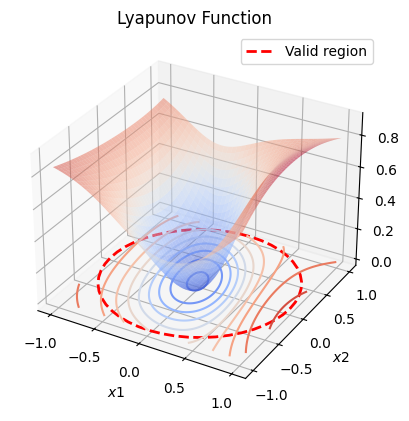

In [16]:
## Plotting results of Lyapunov functions

# %% [code]
import numpy as np
from numpy import *
import random
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
from matplotlib import cm

# %% [code]
def Plot3D(X, Y, V, r):
    # Plot Lyapunov functions
    fig = plt.figure()
    #ax = fig.gca(projection='3d')
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X,Y,V, rstride=5, cstride=5, alpha=0.5, cmap=cm.coolwarm)
    ax.contour(X,Y,V,10, zdir='z', offset=0, cmap=cm.coolwarm)

    # Plot Valid region computed by dReal
    theta = np.linspace(0,2*np.pi,50)
    xc = r*cos(theta)
    yc = r*sin(theta)
    ax.plot(xc[:],yc[:],'r',linestyle='--', linewidth=2 ,label='Valid region')
    plt.legend(loc='upper right')
    return ax

# %% [markdown]

# %% [code]
X = np.linspace(-1, 1, 200)
Y = np.linspace(-1, 1, 200)
x1, x2 = np.meshgrid(X,Y)
x3=0
x4=0
#need to change the V manually
V=tanh((0.47901275753974915 + 0.88362389802932739 * tanh((-0.7853085994720459 + 1.1103259325027466 * x1 - 0.98324275016784668 * x2)) - 0.67091208696365356 * tanh((-0.761829674243927 + 0.15304188430309296 * x1 + 0.03723529726266861 * x2)) - 1.2035249471664429 * tanh((0.58836615085601807 + 1.3773126602172852 * x1 + 0.066441960632801056 * x2)) - 1.0358541011810303 * tanh((0.9080994725227356 - 1.6686844825744629 * x1 - 1.2262518405914307 * x2)) + 0.40420395135879517 * tanh((0.94185495376586914 - 0.10662028938531876 * x1 - 0.030207449570298195 * x2)) + 0.97056913375854492 * tanh((0.9840584397315979 - 0.10522007197141647 * x1 - 0.018120348453521729 * x2))))
ax = Plot3D(x1,x2,V,1)
ax.set_xlabel('$x1$')
ax.set_ylabel('$x2$')
ax.set_zlabel('V')
plt.title('Lyapunov Function')
plt.show()

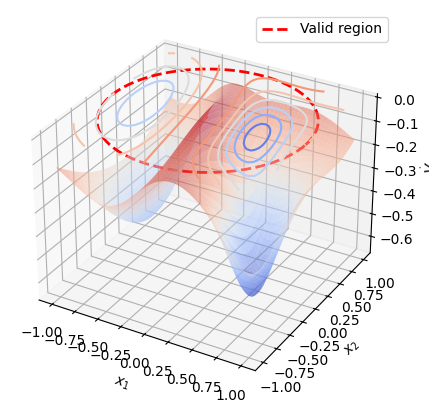

In [22]:
# 定义 Lyapunov 函数 V
def lyapunov_function(x):
    x1, x2 = x[..., 0], x[..., 1]
    V = torch.tanh((0.47901275753974915 + 0.88362389802932739 * torch.tanh((-0.7853085994720459 + 1.1103259325027466 * x1 - 0.98324275016784668 * x2)) - 0.67091208696365356 * torch.tanh((-0.761829674243927 + 0.15304188430309296 * x1 + 0.03723529726266861 * x2)) - 1.2035249471664429 * torch.tanh((0.58836615085601807 + 1.3773126602172852 * x1 + 0.066441960632801056 * x2)) - 1.0358541011810303 * torch.tanh((0.9080994725227356 - 1.6686844825744629 * x1 - 1.2262518405914307 * x2)) + 0.40420395135879517 * torch.tanh((0.94185495376586914 - 0.10662028938531876 * x1 - 0.030207449570298195 * x2)) + 0.97056913375854492 * torch.tanh((0.9840584397315979 - 0.10522007197141647 * x1 - 0.018120348453521729 * x2))))
    return V

# 计算 Lyapunov 函数导数 V_dot
def compute_v_dot(x, model, V_function):
    x = torch.tensor(x, requires_grad=True, dtype=torch.float32).to(device)  # 启用梯度
    V = V_function(x)  # 计算 Lyapunov 函数值
    f = model(x)       # 动态系统模型输出

    # 计算梯度
    grad_V = torch.autograd.grad(V, x, grad_outputs=torch.ones_like(V), create_graph=True)[0]

    # 计算 V_dot = grad_V * f
    V_dot = torch.sum(grad_V * f, dim=-1)
    return V_dot.detach().cpu().numpy()

# 绘制 V_dot 的三维曲面
def plot_v_dot_3d(model, V_function):
    x1_vals = np.linspace(-1, 1, 50)
    x2_vals = np.linspace(-1, 1, 50)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    state_space = np.stack([X1.ravel(), X2.ravel()], axis=1)

    # 计算每个状态点的 V_dot
    V_dot_vals = np.array([compute_v_dot(x, model, V_function) for x in state_space]).reshape(X1.shape)


    # 绘制 3D 曲面
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')
    ax.contour(X1, X2, V_dot_vals, zdir='z', offset=0, cmap='coolwarm', linestyles='solid')
    ax.plot_surface(X1, X2, V_dot_vals, cmap='coolwarm', edgecolor='none', alpha=0.5)
    # ax.set_title(r"$\dot{V}$ Surface (Lyapunov Function Derivative)")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_zlabel(r"$\dot{V}$")
    # ax.set_zlim(-0.4, 0)

    # 绘制 z=0 平面上的半径为 1 的红色虚线圆
    theta = np.linspace(0, 2 * np.pi, 100)
    circle_x = np.cos(theta)
    circle_y = np.sin(theta)
    circle_z = np.zeros_like(theta)  # z = 0 平面
    ax.plot(circle_x, circle_y, circle_z, 'r--', linewidth=2, label='Valid region')
    ax.legend(loc="upper right")
    plt.show()

# 绘制 V_dot 曲面图
plot_v_dot_3d(model_sys, lyapunov_function)

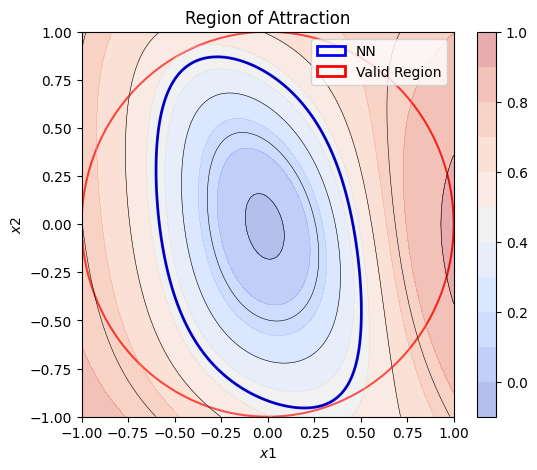

In [ ]:
ax = plt.gca()
# Lyapunov functions
#need to change the V manually

# Vaild Region
C = plt.Circle((0, 0),1, color='r', linewidth=1.5, fill=False)
ax.add_artist(C)

X = np.linspace(-1, 1, 100)
Y = np.linspace(-1, 1, 100)
x1, x2 = np.meshgrid(X, Y)
# successful Lyapunov 0.166
# V=tanh((0.34299883246421814 - 0.51377838850021362 * tanh((-0.63021641969680786 + 0.039138559252023697 * x1 + 0.019295038655400276 * x2)) + 0.6837458610534668 * tanh((-0.57077372074127197 + 1.1493574380874634 * x1 - 0.21827289462089539 * x2)) - 0.89170157909393311 * tanh((0.4375838041305542 + 1.1005779504776001 * x1 + 0.24230770766735077 * x2)) - 0.43985667824745178 * tanh((0.63290220499038696 - 1.3425791263580322 * x1 - 0.36941894888877869 * x2)) + 0.77071291208267212 * tanh((0.98405128717422485 - 0.028912046924233437 * x1 - 0.02438623458147049 * x2)) - 0.32828328013420105 * tanh((1.0038706064224243 + 1.1356333494186401 * x1 - 1.321200966835022 * x2))))+0.0054
# V=tanh((0.34195011854171753 - 0.5064162015914917 * tanh((-0.62281447649002075 + 0.04018745943903923 * x1 + 0.018804918974637985 * x2)) + 0.68180602788925171 * tanh((-0.57067602872848511 + 1.1496646404266357 * x1 - 0.2211742103099823 * x2)) - 0.89131307601928711 * tanh((0.43720659613609314 + 1.1042369604110718 * x1 + 0.23592488467693329 * x2)) - 0.4391646683216095 * tanh((0.63413673639297485 - 1.3445570468902588 * x1 - 0.36462554335594177 * x2)) - 0.32264715433120728 * tanh((0.97943580150604248 + 1.1318031549453735 * x1 - 1.2858430147171021 * x2)) + 0.76929205656051636 * tanh((0.9827648401260376 - 0.028928829357028008 * x1 - 0.022893166169524193 * x2))))
V=tanh((0.47607088088989258 - 0.64680624008178711 * tanh((-0.68710047006607056 + 0.041508235037326813 * x1 + 0.062287122011184692 * x2)) + 0.77832895517349243 * tanh((-0.55561673641204834 + 1.0157153606414795 * x1 - 0.3447079062461853 * x2)) - 0.93503355979919434 * tanh((0.55325311422348022 + 1.1046651601791382 * x1 + 0.32319769263267517 * x2)) - 0.542289137840271 * tanh((0.68727004528045654 - 1.1814959049224854 * x1 - 0.78385728597640991 * x2)) + 0.92637777328491211 * tanh((1.1236069202423096 - 0.033017672598361969 * x1 - 0.010839096270501614 * x2)) - 0.49358639121055603 * tanh((1.3775942325592041 + 0.90817075967788696 * x1 - 1.6903481483459473 * x2))))
# V=tanh((0.52552974224090576 - 0.79435110092163086 * tanh((-0.82535618543624878 + 0.038695119321346283 * x1 + 0.030471388250589371 * x2)) + 0.84909701347351074 * tanh((-0.56317973136901855 + 0.99540877342224121 * x1 - 0.43006885051727295 * x2)) - 0.94720751047134399 * tanh((0.5449870228767395 + 1.1364178657531738 * x1 + 0.52202671766281128 * x2)) - 0.67159038782119751 * tanh((0.82931584119796753 - 1.1491574048995972 * x1 - 1.0939497947692871 * x2)) - 0.61540061235427856 * tanh((1.1768360137939453 + 1.0351219177246094 * x1 - 1.4454421997070312 * x2)) + 0.98493963479995728 * tanh((1.1915280818939209 - 0.027205616235733032 * x1 - 0.028129050508141518 * x2))))
V=tanh((0.53441518545150757 - 0.77491670846939087 * tanh((-0.85598820447921753 + 0.1362377405166626 * x1 + 0.0033061620779335499 * x2)) + 0.81857341527938843 * tanh((-0.60832452774047852 + 1.0721726417541504 * x1 - 0.59580332040786743 * x2)) - 1.0237584114074707 * tanh((0.51349842548370361 + 1.1941918134689331 * x1 + 0.37784445285797119 * x2)) - 0.7630879282951355 * tanh((0.69133216142654419 - 1.3951010704040527 * x1 - 0.74259275197982788 * x2)) + 1.0222123861312866 * tanh((1.1298264265060425 - 0.08715645968914032 * x1 - 0.0044363043271005154 * x2)) - 0.60776859521865845 * tanh((1.3070403337478638 + 0.78133153915405273 * x1 - 1.5515180826187134 * x2))))
V=tanh((0.47901275753974915 + 0.88362389802932739 * tanh((-0.7853085994720459 + 1.1103259325027466 * x1 - 0.98324275016784668 * x2)) - 0.67091208696365356 * tanh((-0.761829674243927 + 0.15304188430309296 * x1 + 0.03723529726266861 * x2)) - 1.2035249471664429 * tanh((0.58836615085601807 + 1.3773126602172852 * x1 + 0.066441960632801056 * x2)) - 1.0358541011810303 * tanh((0.9080994725227356 - 1.6686844825744629 * x1 - 1.2262518405914307 * x2)) + 0.40420395135879517 * tanh((0.94185495376586914 - 0.10662028938531876 * x1 - 0.030207449570298195 * x2)) + 0.97056913375854492 * tanh((0.9840584397315979 - 0.10522007197141647 * x1 - 0.018120348453521729 * x2))))

ax.contour(X,Y,V-0.45,0,linewidths=2, colors='b',linestyles='-') # need to change the value behind

ax.contour(x1,x2,V,8,linewidths=0.4, colors='k')
c1 = ax.contourf(x1,x2,V,10,alpha=0.4,cmap=cm.coolwarm)
plt.colorbar(c1)

plt.title('Region of Attraction')
plt.legend([plt.Rectangle((0,0),1,2,color='b',fill=False,linewidth = 2),plt.Rectangle((0,0),1,2,color='r',fill=False,linewidth = 2,linestyle='-'),plt.Rectangle((0,0),1,2,color='b',fill=False,linewidth = 2),C]\
           ,['NN','Valid Region'],loc='upper right')
plt.xlabel('$x1$')
plt.ylabel('$x2$')
plt.show()

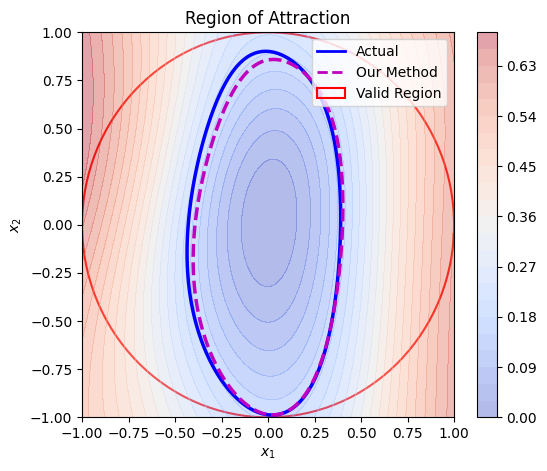

In [ ]:
#compare the result with actual system
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
plt.rcParams['figure.figsize'] = (6, 5)
# 创建画布
ax = plt.gca()

# Valid Region (红色圆圈)
C = plt.Circle((0, 0), 1, color='r', linewidth=1.5, fill=False)
ax.add_artist(C)

# 定义网格
X = np.linspace(-1, 1, 100)
Y = np.linspace(-1, 1, 100)
x1, x2 = np.meshgrid(X, Y)

# 定义 Lyapunov 函数 V1 和 V2 V1 actual V2 NODE
#0.265
# V1=np.tanh((0.43399402499198914 + 0.75664454698562622 * tanh((-0.69954133033752441 + 1.0162184238433838 * x1 - 0.70627248287200928 * x2)) - 0.45877575874328613 * tanh((-0.62467145919799805 + 0.16661365330219269 * x1 + 0.049613021314144135 * x2)) + 0.26460278034210205 * tanh((0.53843885660171509 - 0.2516503632068634 * x1 - 0.073696918785572052 * x2)) - 1.0668764114379883 * tanh((0.56814205646514893 + 1.1851497888565063 * x1 + 0.035966772586107254 * x2)) - 0.83015406131744385 * tanh((0.68230116367340088 - 1.5155531167984009 * x1 - 0.83905011415481567 * x2)) + 0.94384181499481201 * tanh((0.90569931268692017 - 0.13777308166027069 * x1 - 0.039387673139572144 * x2))))+0.008
# V1=np.tanh((0.38428112864494324 + 0.71182191371917725 * tanh((-0.67937463521957397 + 0.97107529640197754 * x1 - 0.36386319994926453 * x2)) - 0.34811162948608398 * tanh((-0.492115318775177 + 0.11608982086181641 * x1 + 0.074724942445755005 * x2)) + 0.2443053275346756 * tanh((0.37890657782554626 - 0.28285875916481018 * x1 - 0.060631345957517624 * x2)) - 0.93082904815673828 * tanh((0.53797465562820435 + 1.00007164478302 * x1 + 0.078204058110713959 * x2)) - 0.62116098403930664 * tanh((0.67712193727493286 - 1.2644052505493164 * x1 - 0.71268129348754883 * x2)) + 0.8661993145942688 * tanh((0.88808923959732056 - 0.10336050391197205 * x1 - 0.031904585659503937 * x2))))
# V2=np.tanh((0.47901275753974915 + 0.88362389802932739 * tanh((-0.7853085994720459 + 1.1103259325027466 * x1 - 0.98324275016784668 * x2)) - 0.67091208696365356 * tanh((-0.761829674243927 + 0.15304188430309296 * x1 + 0.03723529726266861 * x2)) - 1.2035249471664429 * tanh((0.58836615085601807 + 1.3773126602172852 * x1 + 0.066441960632801056 * x2)) - 1.0358541011810303 * tanh((0.9080994725227356 - 1.6686844825744629 * x1 - 1.2262518405914307 * x2)) + 0.40420395135879517 * tanh((0.94185495376586914 - 0.10662028938531876 * x1 - 0.030207449570298195 * x2)) + 0.97056913375854492 * tanh((0.9840584397315979 - 0.10522007197141647 * x1 - 0.018120348453521729 * x2))))
V1=np.tanh((0.34233137965202332 - 0.58169186115264893 * np.tanh((-0.6682390570640564 + 0.019960593432188034 * x1 - 0.020123578608036041 * x2)) + 0.75236839056015015 * np.tanh((-0.53451234102249146 + 1.0965578556060791 * x1 - 0.21427591145038605 * x2)) - 0.90631699562072754 * np.tanh((0.47259703278541565 + 1.1159381866455078 * x1 + 0.26843318343162537 * x2)) - 0.44119027256965637 * np.tanh((0.62250536680221558 - 1.2527687549591064 * x1 - 0.40742474794387817 * x2)) + 0.77197784185409546 * np.tanh((0.98795324563980103 - 0.018966270610690117 * x1 + 0.00268731196410954 * x2)) - 0.33189314603805542 * np.tanh((1.0287587642669678 + 1.0864537954330444 * x1 - 1.2491099834442139 * x2))))
V2=np.tanh((0.34299883246421814 - 0.51377838850021362 * np.tanh((-0.63021641969680786 + 0.039138559252023697 * x1 + 0.019295038655400276 * x2)) + 0.6837458610534668 * np.tanh((-0.57077372074127197 + 1.1493574380874634 * x1 - 0.21827289462089539 * x2)) - 0.89170157909393311 * np.tanh((0.4375838041305542 + 1.1005779504776001 * x1 + 0.24230770766735077 * x2)) - 0.43985667824745178 * np.tanh((0.63290220499038696 - 1.3425791263580322 * x1 - 0.36941894888877869 * x2)) + 0.77071291208267212 * np.tanh((0.98405128717422485 - 0.028912046924233437 * x1 - 0.02438623458147049 * x2)) - 0.32828328013420105 * np.tanh((1.0038706064224243 + 1.1356333494186401 * x1 - 1.321200966835022 * x2))))+0.01
# 绘制 V1 的 ROA (蓝色等高线)
ax.contour(X, Y, V1 - 0.17, levels=[0], linewidths=2.5, colors='b', linestyles='-') #0.265 0.12
# ax.contour(x1, x2, V1, levels=0, linewidths=0.4, colors='k')
# c1 = ax.contourf(x1, x2, V1, levels=8, alpha=0.4, cmap=cm.coolwarm)

# 绘制 V2 的 ROA (紫色等高线)
ax.contour(X, Y, V2 - 0.17, levels=[0], linewidths=2.5, colors='m', linestyles='--')  # 改变值进行分割
# ax.contour(x1, x2, V2, levels=0, linewidths=0.4, colors='k')
c2 = ax.contourf(x1, x2, V2, levels=25, alpha=0.4, cmap=cm.coolwarm)

# # 添加颜色条
# plt.colorbar(c1, label='Actual')
plt.colorbar(c2)
# ax.scatter(0.2, -0.13, color='red', marker='*', s=70, label='(-0.292,0.083)')

# 标题和图例
plt.title('Region of Attraction')
plt.legend([plt.Line2D([0], [0], color='b', lw=2, label='V1 (NN)'),
            plt.Line2D([0], [0], color='m', lw=2, linestyle='--', label='V2 (NN)'),
            C],
           ['Actual', 'Our Method', 'Valid Region'], loc='upper right')

# 坐标轴标签
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')

# 显示图像
plt.show()


In [ ]:
#compare the result with actual system
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
plt.rcParams['figure.figsize'] = (6, 5)
# 创建画布
ax = plt.gca()

# Valid Region (红色圆圈)
C = plt.Circle((0, 0), 1, color='r', linewidth=1.5, fill=False)
ax.add_artist(C)

# 定义网格
X = np.linspace(-1, 1, 100)
Y = np.linspace(-1, 1, 100)
x1, x2 = np.meshgrid(X, Y)

# 定义 Lyapunov 函数 V1 和 V2 V1 actual V2 NODE
V1=np.tanh((0.43399402499198914 + 0.75664454698562622 * tanh((-0.69954133033752441 + 1.0162184238433838 * x1 - 0.70627248287200928 * x2)) - 0.45877575874328613 * tanh((-0.62467145919799805 + 0.16661365330219269 * x1 + 0.049613021314144135 * x2)) + 0.26460278034210205 * tanh((0.53843885660171509 - 0.2516503632068634 * x1 - 0.073696918785572052 * x2)) - 1.0668764114379883 * tanh((0.56814205646514893 + 1.1851497888565063 * x1 + 0.035966772586107254 * x2)) - 0.83015406131744385 * tanh((0.68230116367340088 - 1.5155531167984009 * x1 - 0.83905011415481567 * x2)) + 0.94384181499481201 * tanh((0.90569931268692017 - 0.13777308166027069 * x1 - 0.039387673139572144 * x2))))+0.008

V2 = np.tanh((0.34299883246421814 - 0.51377838850021362 * tanh((-0.63021641969680786 + 0.039138559252023697 * x1 + 0.019295038655400276 * x2)) + 0.6837458610534668 * tanh((-0.57077372074127197 + 1.1493574380874634 * x1 - 0.21827289462089539 * x2)) - 0.89170157909393311 * tanh((0.4375838041305542 + 1.1005779504776001 * x1 + 0.24230770766735077 * x2)) - 0.43985667824745178 * tanh((0.63290220499038696 - 1.3425791263580322 * x1 - 0.36941894888877869 * x2)) + 0.77071291208267212 * tanh((0.98405128717422485 - 0.028912046924233437 * x1 - 0.02438623458147049 * x2)) - 0.32828328013420105 * tanh((1.0038706064224243 + 1.1356333494186401 * x1 - 1.321200966835022 * x2))))+0.0054

# 绘制 V1 的 ROA (蓝色等高线)
ax.contour(X, Y, V1 - 0.176, levels=[0], linewidths=2.5, colors='b', linestyles='-')
# ax.contour(x1, x2, V1, levels=0, linewidths=0.4, colors='k')
# c1 = ax.contourf(x1, x2, V1, levels=8, alpha=0.4, cmap=cm.coolwarm)

# 绘制 V2 的 ROA (紫色等高线)
ax.contour(X, Y, V2 - 0.166, levels=[0], linewidths=2.5, colors='m', linestyles='--')  # 改变值进行分割
# ax.contour(x1, x2, V2, levels=0, linewidths=0.4, colors='k')
c2 = ax.contourf(x1, x2, V2, levels=25, alpha=0.4, cmap=cm.coolwarm)

# # 添加颜色条
# plt.colorbar(c1, label='Actual')
plt.colorbar(c2)

# 标题和图例
plt.title('Region of Attraction')
plt.legend([plt.Line2D([0], [0], color='b', lw=2, label='V1 (NN)'),
            plt.Line2D([0], [0], color='m', lw=2, linestyle='--', label='V2 (NN)'),
            C],
           ['Actual', 'Neural ODE', 'Valid Region'], loc='upper right')

# 坐标轴标签
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')

# 显示图像
plt.show()
